In [1]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [2]:
df, scores = main(2022, 10000)

In [3]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #3616: 1460
Sim #1449: 1430
Sim #7276: 1400
Sim #3507: 1380
Sim #3116: 1370

BOTTOM 5 SCORES
Sim #9049: 190
Sim #7694: 190
Sim #2804: 190
Sim #7536: 200
Sim #2388: 200

AVERAGE SCORE: 519.33


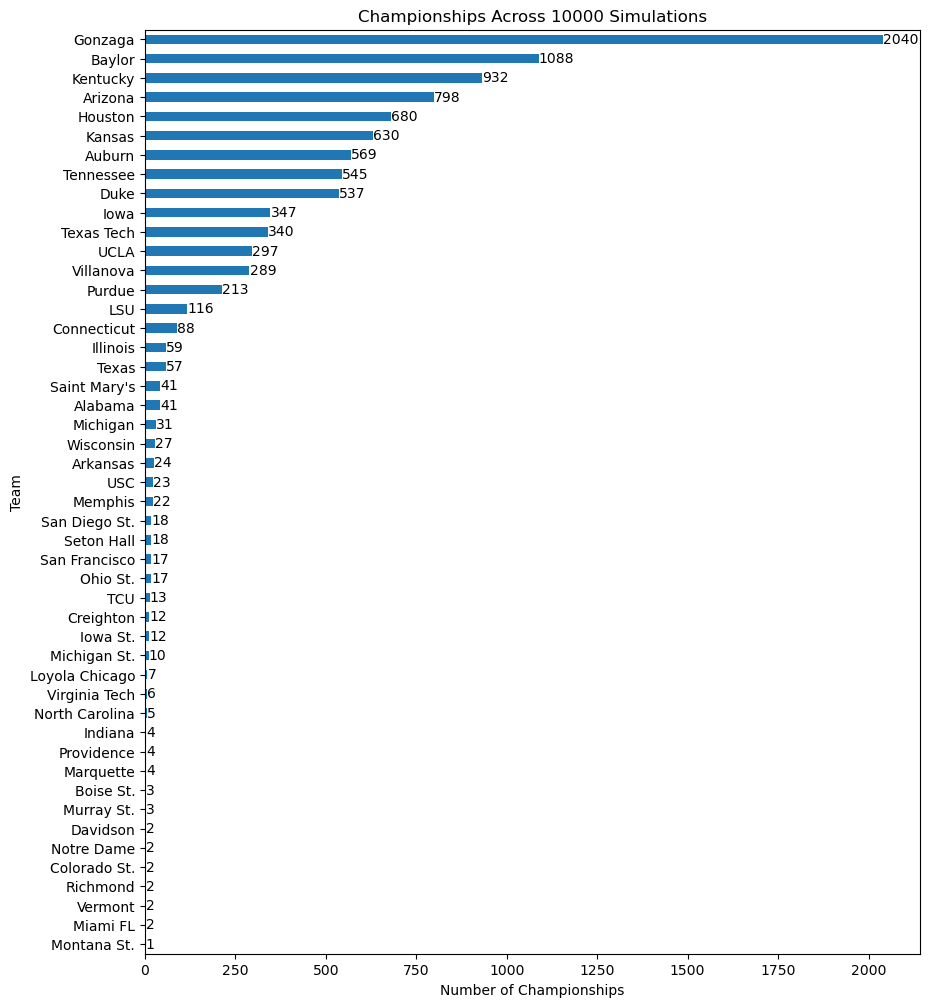

In [4]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 10000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [5]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 10000 Simulations

Gonzaga           2040 --> 20.4%           USC                23 --> 0.23%            Vermont             2 --> 0.02%         
Baylor            1088 --> 10.88%          Memphis            22 --> 0.22%            Montana St.         1 --> 0.01%         
Kentucky          932 --> 9.32%            San Diego St.      18 --> 0.18%            UAB                 0 --> 0.0%          
Arizona           798 --> 7.98%            Seton Hall         18 --> 0.18%            New Mexico St.      0 --> 0.0%          
Houston           680 --> 6.8%             Ohio St.           17 --> 0.17%            South Dakota St.    0 --> 0.0%          
Kansas            630 --> 6.3%             San Francisco      17 --> 0.17%            Chattanooga         0 --> 0.0%          
Auburn            569 --> 5.69%            TCU                13 --> 0.13%            Akron               0 --> 0.0%          
Tennessee         545 --> 5.45%            Creighton          12 -

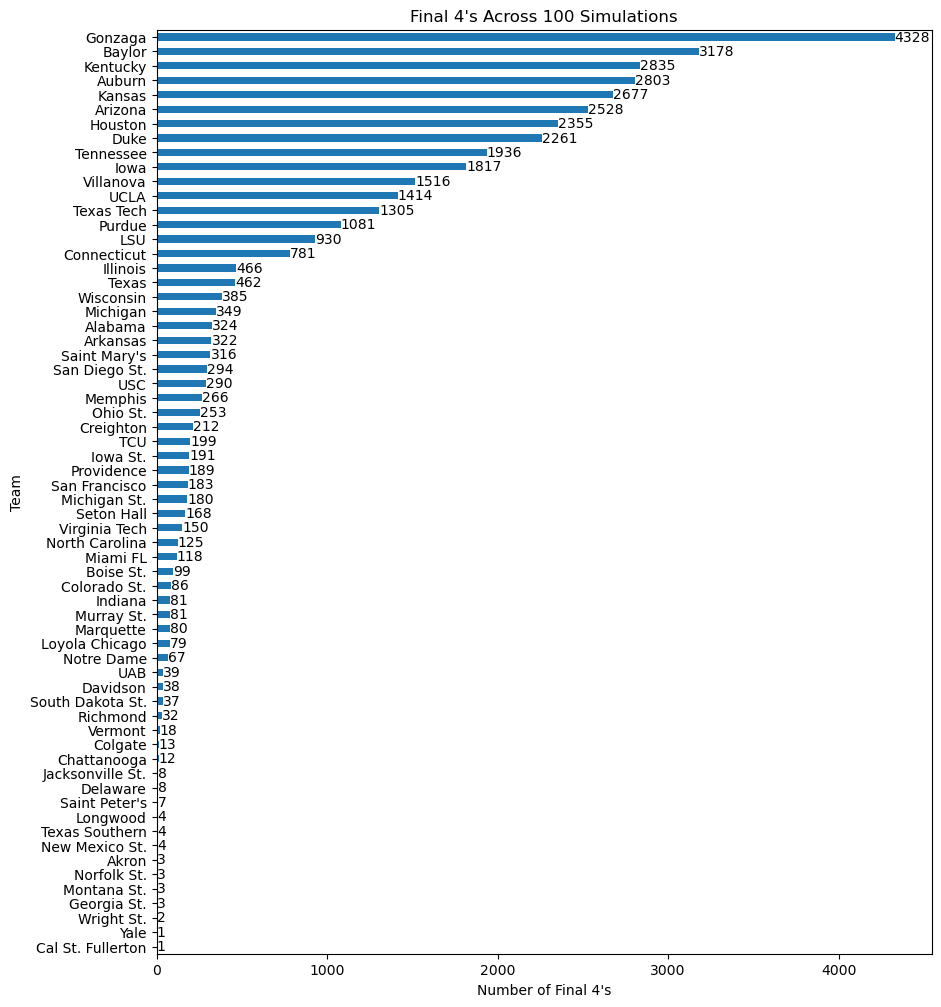

In [6]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 100 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [7]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 10000 Simulations

Gonzaga           4328 --> 43.28%          San Diego St.     294 --> 2.94%            South Dakota St.   37 --> 0.37%         
Baylor            3178 --> 31.78%          USC               290 --> 2.9%             Richmond           32 --> 0.32%         
Kentucky          2835 --> 28.35%          Memphis           266 --> 2.66%            Vermont            18 --> 0.18%         
Auburn            2803 --> 28.03%          Ohio St.          253 --> 2.53%            Colgate            13 --> 0.13%         
Kansas            2677 --> 26.77%          Creighton         212 --> 2.12%            Chattanooga        12 --> 0.12%         
Arizona           2528 --> 25.28%          TCU               199 --> 1.99%            Jacksonville St.    8 --> 0.08%         
Houston           2355 --> 23.55%          Iowa St.          191 --> 1.91%            Delaware            8 --> 0.08%         
Duke              2261 --> 22.61%          Providence        189 --> 1

In [8]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 10000 Simulations

Gonzaga           6131 --> 61.31%          Saint Mary's      845 --> 8.45%            UAB               130 --> 1.3%          
Baylor            5141 --> 51.41%          San Diego St.     842 --> 8.42%            Richmond          127 --> 1.27%         
Auburn            4942 --> 49.42%          Ohio St.          809 --> 8.09%            Vermont           118 --> 1.18%         
Kentucky          4930 --> 49.3%           Michigan St.      739 --> 7.39%            Colgate            67 --> 0.67%         
Duke              4868 --> 48.68%          Memphis           681 --> 6.81%            New Mexico St.     60 --> 0.6%          
Kansas            4355 --> 43.55%          San Francisco     661 --> 6.61%            Saint Peter's      59 --> 0.59%         
Arizona           4028 --> 40.28%          Creighton         654 --> 6.54%            Chattanooga        57 --> 0.57%         
Houston           3766 --> 37.66%          Providence        567 --> 5

In [9]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 10000 Simulations

Baylor            7427 --> 74.27%          Ohio St.          2111 --> 21.11%          Richmond          643 --> 6.43%         
Gonzaga           7382 --> 73.82%          Providence        1964 --> 19.64%          South Dakota St.  622 --> 6.22%         
Duke              7299 --> 72.99%          USC               1884 --> 18.84%          UAB               512 --> 5.12%         
Kentucky          7004 --> 70.04%          San Diego St.     1875 --> 18.75%          Colgate           477 --> 4.77%         
Arizona           6852 --> 68.52%          Michigan St.      1866 --> 18.66%          New Mexico St.    471 --> 4.71%         
Iowa              6771 --> 67.71%          San Francisco     1728 --> 17.28%          Chattanooga       368 --> 3.68%         
Auburn            6748 --> 67.48%          Virginia Tech     1689 --> 16.89%          Saint Peter's     241 --> 2.41%         
Villanova         6453 --> 64.53%          TCU               1625 -->

In [10]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
238907,3733,4,Montana St.,14,0,6,100.0,N/A,13.272,Texas Tech,16.004,Alabama,8.281,Duke,7.661,Gonzaga,9.096,Kentucky,10.252,Illinois,0.000
437139,6831,2,Delaware,15,0,5,100.0,N/A,11.088,Villanova,15.914,Ohio St.,19.752,Colorado St.,8.263,Arizona,9.375,Kansas,22.361,Notre Dame,0.002
145760,2278,3,Akron,13,0,5,100.0,N/A,10.112,UCLA,17.981,Indiana,13.650,North Carolina,16.734,San Francisco,8.892,Gonzaga,8.159,Arizona,0.003
208019,3251,2,Delaware,15,0,5,100.0,N/A,11.088,Villanova,15.914,Ohio St.,19.752,Colorado St.,10.807,Illinois,9.375,Kansas,9.169,Baylor,0.003
403455,6304,4,Vermont,13,0,6,100.0,N/A,24.056,Arkansas,53.398,New Mexico St.,9.386,Gonzaga,14.302,Duke,14.487,Baylor,16.193,Villanova,0.004
129461,2023,4,Davidson,10,0,6,100.0,N/A,34.143,Michigan St.,14.244,Duke,35.978,Texas Tech,12.743,Gonzaga,15.887,Kentucky,15.224,Arizona,0.005
352138,5503,1,Richmond,12,1,6,100.0,N/A,15.039,Iowa,34.972,Providence,32.022,San Diego St.,15.979,Auburn,12.945,Arizona,18.096,Texas Tech,0.006
255807,3997,4,Vermont,13,0,5,100.0,N/A,24.056,Arkansas,24.731,Connecticut,9.386,Gonzaga,14.302,Duke,15.015,Kentucky,29.924,Creighton,0.008
177647,2776,3,Yale,14,0,4,100.0,N/A,14.964,Purdue,10.379,Texas,8.401,Kentucky,8.267,Baylor,9.036,Duke,0.000,N/A,0.010
625663,9776,4,Vermont,13,0,5,100.0,N/A,24.056,Arkansas,24.731,Connecticut,9.386,Gonzaga,14.302,Duke,14.487,Baylor,17.862,Tennessee,0.010


In [12]:
df[df["sim_num"] == 3616].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
231366,3616,1,Kansas,1,6,6,100.0,N/A,88.490,Texas Southern,69.934,San Diego St.,86.593,Richmond,51.855,Auburn,44.078,Houston,78.568,North Carolina,9.623
231399,3616,3,North Carolina,8,5,5,100.0,N/A,57.889,Marquette,19.221,Baylor,46.931,Saint Mary's,18.823,Kentucky,24.161,Duke,21.432,Kansas,0.187
231380,3616,2,Houston,5,3,4,100.0,N/A,84.727,UAB,71.032,Illinois,51.178,Arizona,50.794,Tennessee,55.922,Kansas,0.000,N/A,6.896
231414,3616,4,Duke,2,4,4,100.0,N/A,91.011,Cal St. Fullerton,77.400,Michigan St.,57.789,Texas Tech,32.996,Gonzaga,75.839,North Carolina,0.000,N/A,3.245
231360,3616,1,Auburn,2,1,3,100.0,N/A,89.622,Jacksonville St.,74.631,Miami FL,65.479,LSU,48.145,Kansas,0.000,N/A,0.000,N/A,22.711
231416,3616,4,Gonzaga,1,2,3,100.0,N/A,88.600,Georgia St.,81.108,Memphis,81.488,Connecticut,67.004,Duke,0.000,N/A,0.000,N/A,19.322
231395,3616,3,Kentucky,2,0,3,100.0,N/A,88.254,Saint Peter's,83.268,Murray St.,67.118,Purdue,81.177,North Carolina,0.000,N/A,0.000,N/A,9.284
231388,3616,2,Tennessee,3,1,3,100.0,N/A,86.625,Longwood,76.076,Colorado St.,55.420,Villanova,49.206,Houston,0.000,N/A,0.000,N/A,18.551
231400,3616,3,Purdue,3,2,2,100.0,N/A,85.036,Yale,64.626,Virginia Tech,32.882,Kentucky,0.000,N/A,0.000,N/A,0.000,N/A,36.885
231390,3616,2,Villanova,2,4,2,100.0,N/A,88.912,Delaware,75.158,Loyola Chicago,44.580,Tennessee,0.000,N/A,0.000,N/A,0.000,N/A,37.034


In [13]:
correct = df[df["Wins"] >=5] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 5).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Championship Games: ", len(filtered_df["sim_num"].unique()))

Number of Correct Championship Games:  5


In [15]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Final 4's: ", len(filtered_df["sim_num"].unique()))
print(filtered_df["sim_num"].unique())

Number of Correct Final 4's:  2
[7539 7740]


In [21]:
df[df["sim_num"] == 7740].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
495350,7740,4,Duke,2,4,6,100.0,N/A,91.011,Cal St. Fullerton,77.400,Michigan St.,57.789,Texas Tech,32.996,Gonzaga,75.839,North Carolina,44.376,Kansas,4.521
495302,7740,1,Kansas,1,6,5,100.0,N/A,88.490,Texas Southern,69.934,San Diego St.,85.560,Providence,51.855,Auburn,58.884,Villanova,55.624,Duke,7.175
495335,7740,3,North Carolina,8,5,4,100.0,N/A,57.889,Marquette,19.221,Baylor,26.150,UCLA,38.846,Texas,24.161,Duke,0.000,N/A,0.857
495326,7740,2,Villanova,2,4,4,100.0,N/A,88.912,Delaware,70.587,Ohio St.,80.487,Colorado St.,38.053,Arizona,41.116,Kansas,0.000,N/A,11.319
495296,7740,1,Auburn,2,1,3,100.0,N/A,89.622,Jacksonville St.,74.689,USC,78.217,Iowa St.,48.145,Kansas,0.000,N/A,0.000,N/A,27.150
495352,7740,4,Gonzaga,1,2,3,100.0,N/A,88.600,Georgia St.,81.108,Memphis,81.488,Connecticut,67.004,Duke,0.000,N/A,0.000,N/A,19.322
495340,7740,3,Texas,6,1,3,100.0,N/A,62.154,Virginia Tech,39.699,Purdue,64.389,San Francisco,61.154,North Carolina,0.000,N/A,0.000,N/A,6.172
495312,7740,2,Arizona,1,2,3,100.0,N/A,91.282,Wright St.,75.541,TCU,72.480,Illinois,61.947,Villanova,0.000,N/A,0.000,N/A,19.018
495341,7740,3,UCLA,4,2,2,100.0,N/A,89.888,Akron,78.822,Indiana,73.850,North Carolina,0.000,N/A,0.000,N/A,0.000,N/A,18.528
495348,7740,4,Connecticut,5,0,2,100.0,N/A,83.946,New Mexico St.,60.792,Arkansas,18.512,Gonzaga,0.000,N/A,0.000,N/A,0.000,N/A,41.585


In [22]:
scores[7739]

1070

In [16]:
correct = df[df["Wins"] >=3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Elite 8's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Elite 8's:  0


In [17]:
correct = df[df["Wins"] >=2] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 2).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Sweet 16's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Sweet 16's:  0


In [18]:
correct = df[df["Wins"] >=1] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 1).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Round of 32's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Round of 32's:  0


In [32]:
df[(df["TEAM"] == "Miami FL") & (df["R32_opp"] == "Auburn") & (df["S16_opp"] == "Iowa St.") & (df["E8_opp"] == "Kansas")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
33288,521,1,Miami FL,10,3,3,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,0.000,N/A,0.0,N/A,3.615
110536,1728,1,Miami FL,10,3,4,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,27.244,Tennessee,0.0,N/A,0.496
123848,1936,1,Miami FL,10,3,3,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,0.000,N/A,0.0,N/A,3.615
188232,2942,1,Miami FL,10,3,4,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,27.244,Tennessee,0.0,N/A,0.496
205832,3217,1,Miami FL,10,3,4,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,20.492,Villanova,0.0,N/A,0.542
221064,3455,1,Miami FL,10,3,3,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,0.000,N/A,0.0,N/A,3.615
246984,3860,1,Miami FL,10,3,3,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,0.000,N/A,0.0,N/A,3.615
248392,3882,1,Miami FL,10,3,3,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,0.000,N/A,0.0,N/A,3.615
268552,4197,1,Miami FL,10,3,3,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,0.000,N/A,0.0,N/A,3.615
296328,4631,1,Miami FL,10,3,3,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,0.000,N/A,0.0,N/A,3.615


In [36]:
df[df["sim_num"] == 5688].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
363984,5688,2,Arizona,1,2,6,100.0,N/A,91.282,Wright St.,74.642,Seton Hall,48.822,Houston,55.198,Tennessee,57.722,Kansas,44.219,Baylor,4.687
364001,5688,3,Baylor,1,1,5,100.0,N/A,91.192,Norfolk St.,80.779,North Carolina,73.537,Saint Mary's,83.880,Murray St.,61.215,Duke,55.781,Arizona,12.299
364022,5688,4,Duke,2,4,4,100.0,N/A,91.011,Cal St. Fullerton,77.400,Michigan St.,57.789,Texas Tech,76.211,Boise St.,38.785,Baylor,0.000,N/A,18.992
363974,5688,1,Kansas,1,6,4,100.0,N/A,88.490,Texas Southern,75.256,Creighton,85.560,Providence,84.122,Miami FL,42.278,Arizona,0.000,N/A,27.666
364018,5688,4,Boise St.,8,0,3,100.0,N/A,41.394,Memphis,15.300,Gonzaga,41.772,Arkansas,23.789,Duke,0.000,N/A,0.000,N/A,2.016
363996,5688,2,Tennessee,3,1,3,100.0,N/A,86.625,Longwood,63.213,Michigan,55.420,Villanova,44.802,Arizona,0.000,N/A,0.000,N/A,16.751
364005,5688,3,Murray St.,7,1,3,100.0,N/A,43.306,San Francisco,16.732,Kentucky,34.252,Texas,16.120,Baylor,0.000,N/A,0.000,N/A,2.082
363976,5688,1,Miami FL,10,3,3,100.0,N/A,38.535,USC,25.369,Auburn,43.955,Iowa St.,15.878,Kansas,0.000,N/A,0.000,N/A,3.615
363998,5688,2,Villanova,2,4,2,100.0,N/A,88.912,Delaware,70.587,Ohio St.,44.580,Tennessee,0.000,N/A,0.000,N/A,0.000,N/A,34.782
363988,5688,2,Houston,5,3,2,100.0,N/A,84.727,UAB,71.032,Illinois,51.178,Arizona,0.000,N/A,0.000,N/A,0.000,N/A,29.383


In [30]:
df[df["sim_num"] == 6741].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
431376,6741,2,Arizona,1,2,6,100.0,N/A,91.282,Wright St.,75.541,TCU,48.822,Houston,61.947,Villanova,56.554,Auburn,62.282,Duke,7.346
431414,6741,4,Duke,2,4,5,100.0,N/A,91.011,Cal St. Fullerton,77.400,Michigan St.,83.178,Notre Dame,32.996,Gonzaga,65.710,Texas,37.718,Arizona,7.912
431360,6741,1,Auburn,2,1,4,100.0,N/A,89.622,Jacksonville St.,74.689,USC,87.387,Colgate,52.259,Iowa,43.446,Arizona,0.000,N/A,17.288
431404,6741,3,Texas,6,1,4,100.0,N/A,62.154,Virginia Tech,39.699,Purdue,65.748,Murray St.,26.268,Baylor,34.290,Duke,0.000,N/A,2.800
431416,6741,4,Gonzaga,1,2,3,100.0,N/A,88.600,Georgia St.,81.108,Memphis,81.488,Connecticut,67.004,Duke,0.000,N/A,0.000,N/A,19.322
431363,6741,1,Iowa,5,0,3,100.0,N/A,84.961,Richmond,86.523,South Dakota St.,61.740,Creighton,47.741,Auburn,0.000,N/A,0.000,N/A,23.718
431390,6741,2,Villanova,2,4,3,100.0,N/A,88.912,Delaware,70.587,Ohio St.,80.487,Colorado St.,38.053,Arizona,0.000,N/A,0.000,N/A,31.292
431393,6741,3,Baylor,1,1,3,100.0,N/A,91.192,Norfolk St.,80.779,North Carolina,80.262,Indiana,73.732,Texas,0.000,N/A,0.000,N/A,15.531
431421,6741,4,Notre Dame,11,1,2,100.0,N/A,42.909,Alabama,27.047,Texas Tech,16.822,Duke,0.000,N/A,0.000,N/A,0.000,N/A,9.653
431380,6741,2,Houston,5,3,2,100.0,N/A,84.727,UAB,71.032,Illinois,51.178,Arizona,0.000,N/A,0.000,N/A,0.000,N/A,29.383


In [37]:
df[(df["TEAM"] == "Virginia Tech") & (df["Sim_Wins"] == 6)]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
179438,2804,3,Virginia Tech,11,0,6,100.0,N/A,37.846,Texas,35.374,Purdue,21.642,Kentucky,58.670,Indiana,57.447,Boise St.,23.403,Arizona,0.229
306094,4783,3,Virginia Tech,11,0,6,100.0,N/A,37.846,Texas,88.538,Yale,52.257,San Francisco,46.440,Saint Mary's,29.553,Duke,23.403,Arizona,0.562
387182,6050,3,Virginia Tech,11,0,6,100.0,N/A,37.846,Texas,35.374,Purdue,52.257,San Francisco,27.399,UCLA,30.738,Texas Tech,23.403,Arizona,0.138
489646,7651,3,Virginia Tech,11,0,6,100.0,N/A,37.846,Texas,35.374,Purdue,52.257,San Francisco,19.696,Baylor,16.589,Gonzaga,28.703,Tennessee,0.066
570030,8907,3,Virginia Tech,11,0,6,100.0,N/A,37.846,Texas,35.374,Purdue,21.642,Kentucky,27.399,UCLA,29.553,Duke,58.818,Ohio St.,0.138
581422,9085,3,Virginia Tech,11,0,6,100.0,N/A,37.846,Texas,35.374,Purdue,54.864,Murray St.,19.696,Baylor,16.589,Gonzaga,54.321,San Diego St.,0.130


In [23]:
df.to_csv("../../data/2022_10000sims0.csv")